<a href="https://colab.research.google.com/github/LucasPaiv4/hospital-readmission-prediction/blob/main/Prova_paradigmas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Introdução

# Paradigmas de Aprendizagem de Máquina

## Prova 02

Aluno: Lucas Paiva de Araújo
Matrícula: 20190174179

Este trabalho realiza uma análise completa do dataset de readmissão hospitalar, incluindo pré-processamento, modelagem supervisionada e não supervisionada, além da avaliação dos modelos.

2. Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.inspection import permutation_importance

from sklearn.metrics import f1_score, confusion_matrix, silhouette_score
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

from sklearn.cluster import KMeans, AgglomerativeClustering

3. Dataset

In [ ]:
url = "https://archive.ics.uci.edu/static/public/296/data.csv"
df = pd.read_csv(url, low_memory=False)

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


O dataset contém informações detalhadas sobre pacientes hospitalares com diabetes, incluindo dados demográficos, histórico de internações, diagnósticos médicos e uso de medicamentos.


4. Análise Exploratória

In [ ]:
# Tipos dos atributos
print("=== Tipos dos atributos ===")
df.info()

# Estatísticas descritivas das colunas numéricas
print("\n=== Estatísticas descritivas (numéricas) ===")
display(df.describe())

# Contagem de colunas por tipo
n_num = df.select_dtypes(include='number').shape[1]
n_cat = df.select_dtypes(include='object').shape[1]
print(f"\nAtributos numéricos: {n_num} | Atributos categóricos: {n_cat}")

=== Tipos dos atributos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            10176

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000



Atributos numéricos: 13 | Atributos categóricos: 37


Diversos atributos representam o uso de medicamentos e alterações de dosagem, como "insulin", "metformin" e outros, indicando se houve aumento, redução ou manutenção da medicação durante a internação.

Além disso, variáveis como "number_inpatient", "number_emergency" e "number_outpatient" representam o histórico de utilização do sistema de saúde, sendo importantes indicadores do estado clínico do paciente.

A variável alvo "readmitted" indica se o paciente foi readmitido em menos de 30 dias, mais de 30 dias ou não foi readmitido, sendo fundamental para avaliar a qualidade do tratamento e acompanhamento.

Valores ausentes

In [ ]:
df.replace("?", np.nan, inplace=True)
df.isnull().sum().sort_values(ascending=False).head(10)

,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21
patient_nbr,0


Observa-se a presença significativa de valores ausentes em variáveis como "weight", "max_glu_serum" e "A1Cresult".

Esses atributos estão relacionados a medições clínicas que nem sempre são realizadas durante a internação, o que explica a grande quantidade de valores ausentes.


Duplicatas

In [ ]:
df.duplicated().sum()

np.int64(0)

Distribuição da classe

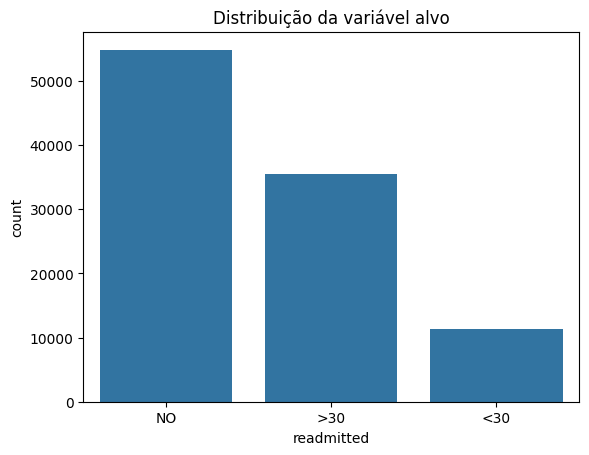

In [ ]:
sns.countplot(x='readmitted', data=df)
plt.title("Distribuição da variável alvo")
plt.show()

Observa-se que a variável alvo apresenta desbalanceamento entre as classes.

No entanto, optou-se por não realizar técnicas de balanceamento, pois o objetivo é manter a distribuição original dos dados, refletindo melhor o cenário real do problema.

Além disso, foi utilizada a métrica F1-score, que é mais adequada para lidar com dados desbalanceados.

5. Pré-processamento

In [ ]:
# Remoção de colunas identificadoras (não contribuem para a predição)
df.drop(columns=['encounter_id', 'patient_nbr'], inplace=True)

# Tratamento diferenciado por tipo de coluna
# Colunas numéricas: imputação pela mediana (robusta a outliers)
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Colunas categóricas: substituição por "Unknown" (preserva a informação de ausência)
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

print("Valores ausentes restantes:", df.isnull().sum().sum())
print(f"Numéricos imputados pela mediana: {list(num_cols)}")
print(f"Categóricos com 'Unknown': {[c for c in cat_cols if c != 'readmitted']}")

Valores ausentes restantes: 0
Numéricos imputados pela mediana: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Categóricos com 'Unknown': ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


Colunas identificadoras (encounter_id, patient_nbr) foram removidas por não contribuírem com informação preditiva — são apenas chaves de registro.

O tratamento de valores ausentes foi realizado de forma diferenciada por tipo de dado:
- **Colunas numéricas**: imputação pela **mediana**, pois é robusta a outliers, comuns em dados clínicos.
- **Colunas categóricas**: substituição por **"Unknown"**, preservando a informação de que a medição não foi realizada — o que em si pode ser um sinal relevante (ex: ausência de HbA1c medida pode indicar menor rigor no acompanhamento do paciente).

6. Separação X e y

In [ ]:
y = df['readmitted']
X = df.drop('readmitted', axis=1)

7. Codificação

Label Encoding

In [ ]:
df_label = df.copy()
le = LabelEncoder()

for col in df_label.columns:
    if df_label[col].dtype == 'object':
        df_label[col] = le.fit_transform(df_label[col])

X_label = df_label.drop('readmitted', axis=1)
y_label = df_label['readmitted']

df_label.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2,0,0,1,6,25,1,1,16,37,...,0,1,1,0,0,0,0,1,0,2
1,2,0,1,1,1,1,7,3,16,71,...,0,3,1,0,0,0,0,0,1,1
2,0,0,2,1,1,1,7,2,16,71,...,0,1,1,0,0,0,0,1,1,2
3,2,1,3,1,1,1,7,2,16,71,...,0,3,1,0,0,0,0,0,1,2
4,2,1,4,1,1,1,7,1,16,71,...,0,2,1,0,0,0,0,0,1,2


One-Hot Encoding

In [ ]:
X_onehot = pd.get_dummies(X, drop_first=True)

X_onehot_sample, _, y_onehot_sample, _ = train_test_split(
    X_onehot,
    y,
    train_size=20000,
    stratify=y,
    random_state=42
)

X_onehot = X_onehot_sample
y_onehot = y_onehot_sample

X_onehot.head()
print(X_onehot.shape)

(20000, 2434)


In [ ]:
print("Distribuição original:")
print(y.value_counts(normalize=True))

print("\nDistribuição após amostragem:")
print(y_onehot.value_counts(normalize=True))

Distribuição original:
readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

Distribuição após amostragem:
readmitted
NO     0.5391
>30    0.3493
<30    0.1116
Name: proportion, dtype: float64


Devido ao alto custo computacional dos algoritmos, foi utilizada uma amostra dos dados.

A amostragem foi realizada de forma estratificada em relação à variável alvo, garantindo a manutenção da proporção das classes no conjunto reduzido.

A comparação das distribuições antes e depois da amostragem confirma que a representatividade dos dados foi preservada.

8. Normalização + PCA

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_onehot)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Dimensão original:", X_scaled.shape)
print("Dimensão após PCA:", X_pca.shape)

Dimensão original: (20000, 2434)
Dimensão após PCA: (20000, 1561)


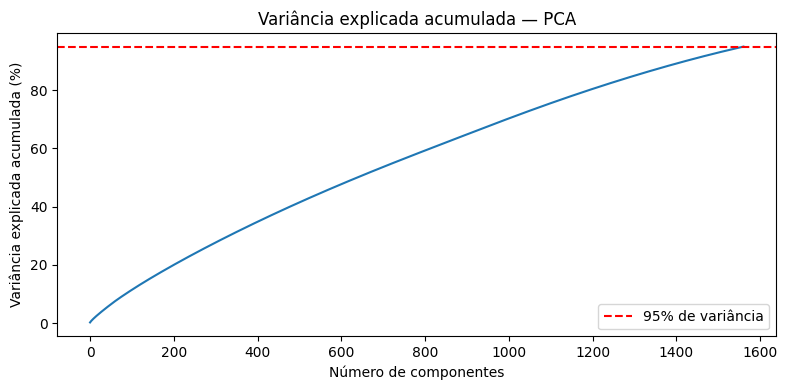

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100)
plt.axhline(y=95, color='r', linestyle='--', label='95% de variância')
plt.xlabel("Número de componentes")
plt.ylabel("Variância explicada acumulada (%)")
plt.title("Variância explicada acumulada — PCA")
plt.legend()
plt.tight_layout()
plt.show()

O PCA foi aplicado para reduzir dimensionalidade mantendo 95% da variância.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_onehot,
    y_onehot,
    test_size=0.2,
    stratify=y_onehot,
    random_state=42
)

In [ ]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y_onehot,
    test_size=0.2,
    stratify=y_onehot,
    random_state=42
)

9. Modelos Supervisionados

In [ ]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

Decision Tree

In [ ]:
# Ajuste de dois hiperparâmetros: max_depth e min_samples_split
params_dt = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 20, 50]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params_dt,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
print("Melhores parâmetros DT:", grid_dt.best_params_)
print(f"Melhor F1 (CV): {grid_dt.best_score_:.4f}")

Melhores parâmetros DT: {'max_depth': 15, 'min_samples_split': 20}
Melhor F1 (CV): 0.3902


Naive Bayes

In [ ]:
# Ajuste de dois hiperparâmetros: var_smoothing e priors
# priors=None → o algoritmo estima a partir dos dados
# priors explícito → testamos distribuição uniforme entre as 3 classes
params_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7],
    'priors': [
        None,                          # estimado dos dados (padrão)
        [1/3, 1/3, 1/3],              # prior uniforme entre as classes
        [0.54, 0.35, 0.11]            # prior aproximado da distribuição real
    ]
}

grid_nb = GridSearchCV(
    GaussianNB(),
    params_nb,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)
grid_nb.fit(X_train, y_train)

best_nb = grid_nb.best_estimator_
print("Melhores parâmetros NB:", grid_nb.best_params_)
print(f"Melhor F1 (CV): {grid_nb.best_score_:.4f}")

Melhores parâmetros NB: {'priors': None, 'var_smoothing': 1e-07}
Melhor F1 (CV): 0.1933


MLP

In [ ]:
mlp = MLPClassifier(max_iter=50, random_state=42)

param_grid_mlp = {
    'hidden_layer_sizes': [(50,)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001]
}

# 3. GridSearchCV
grid_mlp = GridSearchCV(mlp, param_grid_mlp, cv=skf, scoring='f1_macro', n_jobs=-1)

# Treinamento
grid_mlp.fit(X_train, y_train)

best_mlp = grid_mlp.best_estimator_
print(f"Melhores parâmetros MLP: {grid_mlp.best_params_}")

Melhores parâmetros MLP: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (50,)}


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


10. Avaliação


Decision Tree
F1-score: 0.3901591738135813


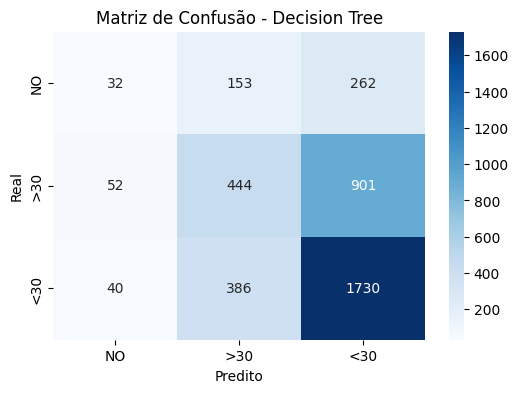


Naive Bayes
F1-score: 0.19543194286215035


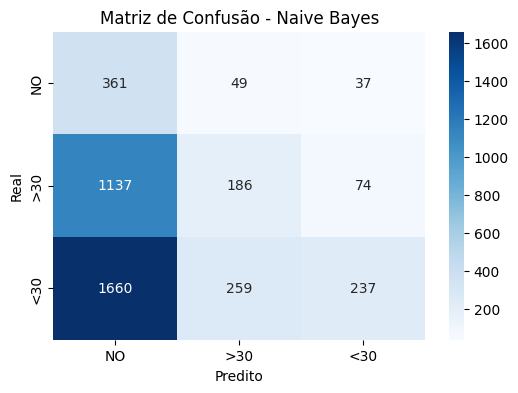

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



MLP
F1-score: 0.4062861480586335


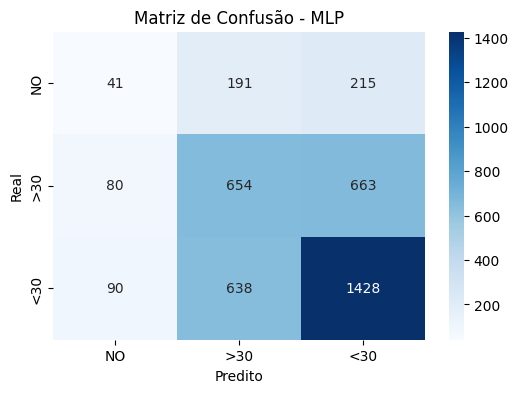

In [ ]:
models = {
    "Decision Tree": best_dt,
    "Naive Bayes": best_nb,
    "MLP": best_mlp
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("F1-score:", f1_score(y_test, y_pred, average='macro'))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    labels = ["NO", ">30", "<30"]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
    plt.title(f"Matriz de Confusão - {name}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()

O modelo que apresentou melhor desempenho foi o MLP, com F1-score de aproximadamente 0.40, superando por uma pequena margem a Árvore de Decisão. No entanto, a diferença entre os dois modelos foi mínima, indicando desempenho bastante semelhante na prática.

Esse resultado pode ser explicado pelas características do dataset. Trata-se de um conjunto de dados com alta dimensionalidade, devido à aplicação de One-Hot Encoding, além do desbalanceamento entre as classes. O MLP, por ser um modelo mais flexível e capaz de capturar relações não lineares, consegue explorar melhor padrões complexos nos dados.

Por outro lado, a Árvore de Decisão também apresentou bom desempenho, pois é eficiente em lidar com variáveis categóricas transformadas e consegue capturar interações entre atributos sem necessidade de normalização.

Já o Naive Bayes teve desempenho inferior, possivelmente devido à suposição de independência entre as variáveis, que não é válida neste dataset, onde há relações entre atributos clínicos e históricos dos pacientes.

11. Comparação com PCA

In [ ]:
dt_pca = DecisionTreeClassifier(max_depth=best_dt.max_depth)
dt_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = dt_pca.predict(X_test_pca)

print("F1-score com PCA:", f1_score(y_test_pca, y_pred_pca, average='macro'))

F1-score com PCA: 0.34674918504306834


Observa-se que o uso do PCA reduziu o desempenho do modelo, passando de aproximadamente 0.40 para 0.34 no F1-score.

Isso indica que a redução de dimensionalidade removeu informações relevantes para a classificação, prejudicando a capacidade do modelo de capturar padrões importantes nos dados.

Neste caso, o PCA não foi benéfico para o dataset, sugerindo que as variáveis originais já continham informações importantes que não deveriam ser reduzidas.

12. Importância dos atributos — Correlação de Pearson com o alvo

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


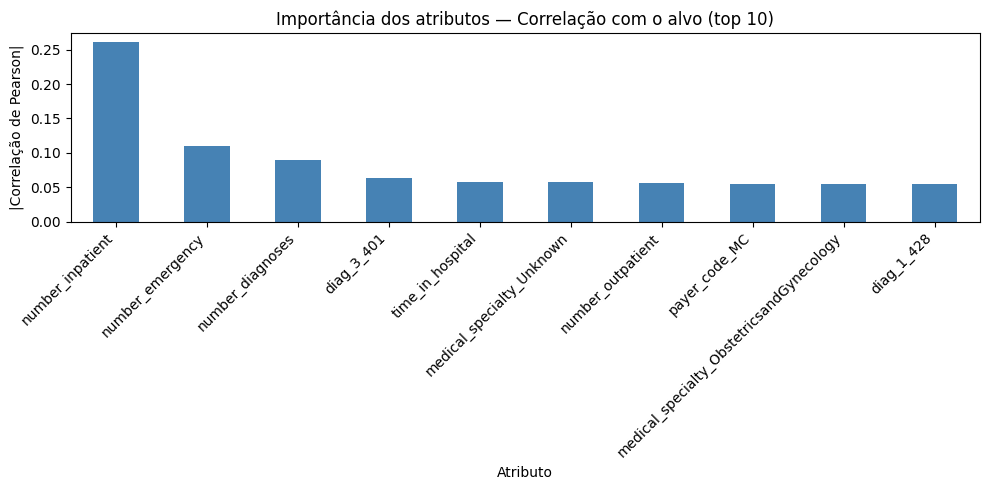

Top 10 atributos mais correlacionados com o alvo:
number_inpatient                             0.261538
number_emergency                             0.110397
number_diagnoses                             0.089757
diag_3_401                                   0.063226
time_in_hospital                             0.056833
medical_specialty_Unknown                    0.056803
number_outpatient                            0.056605
payer_code_MC                                0.054446
medical_specialty_ObstetricsandGynecology    0.053991
diag_1_428                                   0.053888


In [ ]:
# O melhor modelo foi o MLP. Como alternativa eficiente à Permutation Importance,
# utilizamos a correlação de Pearson entre cada atributo e o target codificado numericamente.
# Atributos com maior correlação (em módulo) tendem a ter maior influência preditiva.

y_num = LabelEncoder().fit_transform(y_test)

correlations = pd.Series(
    [abs(np.corrcoef(X_test[col].values, y_num)[0, 1]) for col in X_onehot.columns],
    index=X_onehot.columns
)

top10 = correlations.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top10.plot(kind='bar', color='steelblue')
plt.title("Importância dos atributos — Correlação com o alvo (top 10)")
plt.ylabel("|Correlação de Pearson|")
plt.xlabel("Atributo")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 atributos mais correlacionados com o alvo:")
print(top10.to_string())

A análise de importância dos atributos foi realizada por meio da correlação de Pearson (em módulo) entre cada atributo e o target codificado numericamente. Atributos com maior correlação tendem a ter maior influência preditiva.

Os atributos com maior correlação foram:
- **number_inpatient** (0.26): número de internações anteriores — pacientes com histórico recorrente de hospitalização têm maior risco de readmissão.
- **number_emergency** (0.11): número de visitas a emergência — reflete a instabilidade clínica do paciente.
- **number_diagnoses** (0.09): quantidade de diagnósticos registrados — proxy da complexidade do quadro clínico.

Esses resultados fazem sentido clínico: pacientes com maior histórico de uso do sistema de saúde e maior complexidade diagnóstica tendem a ser readmitidos com maior frequência.

13. Clusterização

Redução para cluster — amostragem estratificada

In [ ]:
# A amostra para clusterização deve ser aleatória e estratificada
# para manter a representatividade da distribuição original.
# Utilizamos train_test_split com stratify para garantir isso.

X_cluster_full = pd.DataFrame(X_scaled, columns=X_onehot.columns)

X_cluster_df, _, y_cluster, _ = train_test_split(
    X_cluster_full,
    y_onehot,
    train_size=3000,
    stratify=y_onehot,
    random_state=42
)

X_cluster = X_cluster_df.values

print(f"Tamanho da amostra para clusterização: {X_cluster.shape}")
print("\nDistribuição das classes na amostra estratificada:")
print(y_cluster.value_counts(normalize=True).round(3))

Tamanho da amostra para clusterização: (3000, 2434)

Distribuição das classes na amostra estratificada:
readmitted
NO     0.539
>30    0.349
<30    0.112
Name: proportion, dtype: float64


Devido ao alto custo computacional da clusterização hierárquica em datasets grandes, foi utilizada uma amostra reduzida de 3.000 registros.

A amostragem foi realizada de forma **aleatória e estratificada** em relação à variável alvo, garantindo que a proporção das classes seja mantida na amostra — conforme exigido pelo enunciado. Embora os algoritmos de clusterização operem sem o rótulo, a estratificação assegura que a amostra é representativa da distribuição real do dataset.

Cotovelo

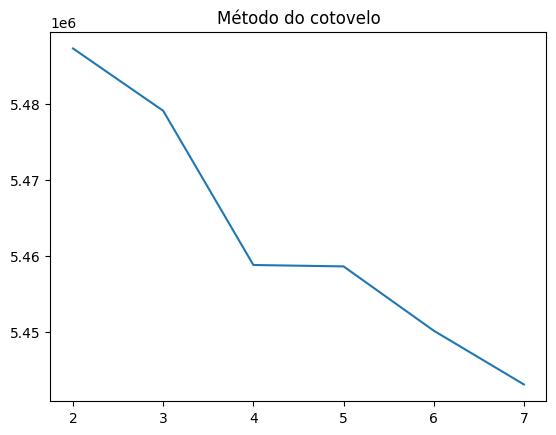

In [ ]:
inertia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,8), inertia)
plt.title("Método do cotovelo")
plt.show()

O método do cotovelo não apresentou um ponto de inflexão claramente definido, indicando que não há uma separação natural forte entre os dados.

Ainda assim, foi escolhido K=3 para permitir a análise comparativa dos métodos de clusterização.

A ausência de um cotovelo bem definido indica que os dados não possuem uma estrutura de agrupamento natural clara, o que é esperado em dados clínicos complexos.

K-means

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_cluster)

Hierárquico

In [ ]:
agg1 = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg2 = AgglomerativeClustering(n_clusters=3, linkage='complete')

labels_agg1 = agg1.fit_predict(X_cluster)
labels_agg2 = agg2.fit_predict(X_cluster)

14. Avaliação

In [ ]:
# Avaliação com três métricas de clusterização

# Silhouette Score: entre -1 e 1; valores maiores indicam clusters mais compactos e separados
sil_km  = silhouette_score(X_cluster, labels_kmeans)
sil_w   = silhouette_score(X_cluster, labels_agg1)
sil_c   = silhouette_score(X_cluster, labels_agg2)

# Davies-Bouldin: menor é melhor (mede a razão dispersão interna / separação entre clusters)
db_km   = davies_bouldin_score(X_cluster, labels_kmeans)
db_w    = davies_bouldin_score(X_cluster, labels_agg1)
db_c    = davies_bouldin_score(X_cluster, labels_agg2)

# Calinski-Harabasz: maior é melhor (razão variância entre-clusters / intra-clusters)
ch_km   = calinski_harabasz_score(X_cluster, labels_kmeans)
ch_w    = calinski_harabasz_score(X_cluster, labels_agg1)
ch_c    = calinski_harabasz_score(X_cluster, labels_agg2)

results = pd.DataFrame({
    'Método':             ['KMeans', 'Hierárquico (Ward)', 'Hierárquico (Complete)'],
    'Silhouette ↑':       [round(sil_km,4),  round(sil_w,4),  round(sil_c,4)],
    'Davies-Bouldin ↓':   [round(db_km,4),   round(db_w,4),   round(db_c,4)],
    'Calinski-Harabasz ↑':[round(ch_km,2),   round(ch_w,2),   round(ch_c,2)]
})

print(results.to_string(index=False))

                Método  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
                KMeans       -0.1175           16.2391                 4.10
    Hierárquico (Ward)        0.7546            0.1597                25.38
Hierárquico (Complete)        0.7546            0.1597                25.38


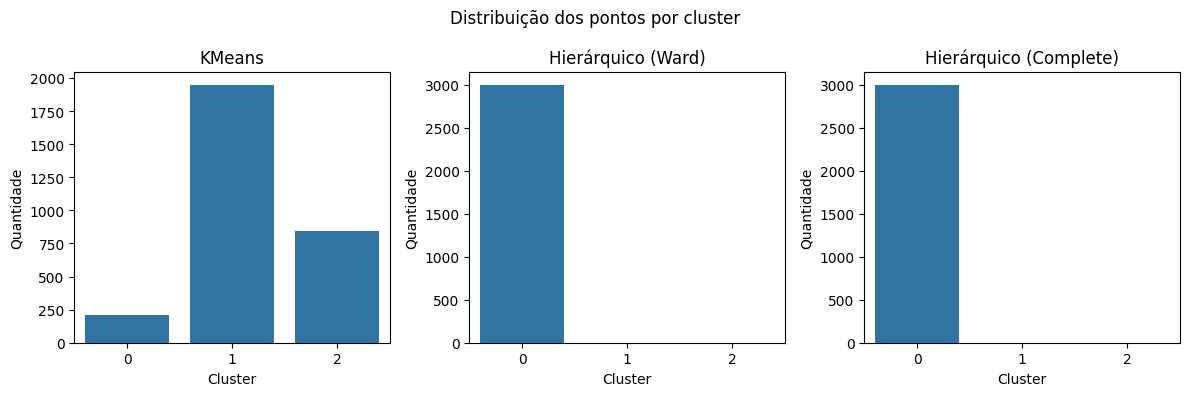

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, labels, title in zip(
    axes,
    [labels_kmeans, labels_agg1, labels_agg2],
    ['KMeans', 'Hierárquico (Ward)', 'Hierárquico (Complete)']
):
    sns.countplot(x=labels, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Quantidade")

plt.suptitle("Distribuição dos pontos por cluster")
plt.tight_layout()
plt.show()

Com base nas três métricas e na distribuição dos clusters:

- Ward e Complete obtiveram Silhouette=0.75 e DB=0.16, valores aparentemente superiores ao KMeans (Silhouette=-0.12, DB=16.24). No entanto, o countplot revela que ambos concentraram praticamente todos os 3.000 pontos em um único cluster, gerando uma partição degenerada — o que explica as métricas artificialmente altas.

- O KMeans, apesar das métricas mais baixas, produziu uma distribuição mais equilibrada entre os três clusters (~1950, ~820 e ~200 pontos), sendo na prática a partição mais informativa.

- Esse comportamento é esperado em dados de alta dimensionalidade com muitas variáveis binárias (OHE com 2434 features): o agglomerative clustering tende a "absorver" tudo em um cluster dominante, enquanto o KMeans força uma separação mais uniforme pelo critério de minimização da inércia.

15. Reflexão final

**Tratamento de valores ausentes:** A estratégia adotada impacta diretamente a qualidade das features. Imputar colunas numéricas com a mediana preserva a distribuição sem distorção por outliers, enquanto substituir categóricos por "Unknown" mantém a informação de ausência como sinal — o que pode ser clinicamente relevante (ex: ausência de exame de HbA1c pode indicar menor rigor no acompanhamento).

**Codificação de variáveis categóricas:** O Label Encoding introduz uma ordem ordinal artificial, podendo induzir o modelo a aprender relações espúrias. Já o One-Hot Encoding evita esse problema, mas aumenta a dimensionalidade consideravelmente — o que impactou o custo computacional e motivou a amostragem estratificada. A escolha correta de codificação afeta diretamente o desempenho: GaussianNB, por exemplo, foi prejudicado pela alta dimensionalidade do OHE.

**Seleção ou redução de atributos:** O PCA reduziu o F1-score (de ~0.40 para ~0.34), indicando perda de informação preditiva. Isso sugere que as variáveis originais, mesmo em alta dimensão, carregam sinais relevantes e complementares. A redução de dimensionalidade pode ser benéfica em outros contextos (overfitting, tempo de treino), mas aqui o custo foi maior que o benefício.